# Experiment of impact of continents against efficiency

*Yirang Liu*

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
#prep overall data
df = pd.read_parquet(
    "https://github.com/monatagelsir7/enivornmental_impact_of_aviation/raw/refs/heads/Shawn/0.Data_after_cleaning/cleaned_aviation_data_v3.parquet"
)
df = df.drop_duplicates()

X = df[[
    'airline_iata', 'acft_class', 'departure_country', 'departure_continent',
    'arrival_country', 'arrival_continent', 'domestic', 'ask', 'rpk',
    'fuel_burn', 'iata_departure', 'iata_arrival', 'acft_icao'
]]
y = df['co2_per_distance']

X = pd.get_dummies(X, drop_first=True)

continent_summary = df.groupby('departure_continent')['co2_per_distance'].agg(['count', 'mean', 'median']).reset_index()
print(continent_summary)


  departure_continent   count         mean       median
0                  AF    8243  1824.137862   329.782932
1                  AS   37622  5512.870789  1031.447236
2                  EU  105314  1095.078701   166.792945
3                  NA  126287  1069.843558    17.245780
4                  OC    2878  4995.068781  1049.765933
5                  SA    5732  4826.791865   485.993536


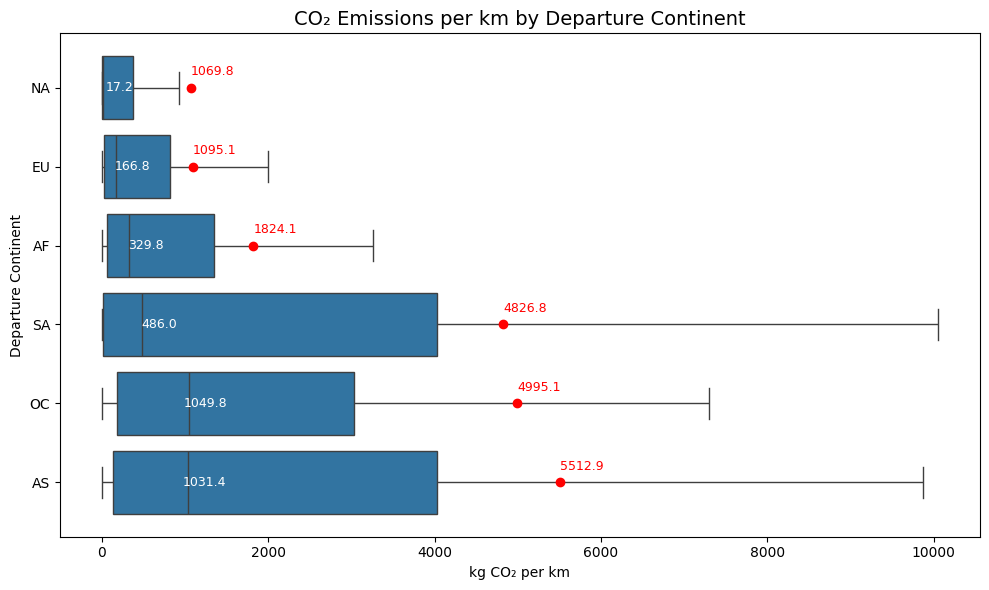

In [3]:
# Specify desired order
continent_order = ['NA', 'EU', 'AF', 'SA', 'OC', 'AS']

# Compute means and medians
continent_means = df.groupby('departure_continent')['co2_per_distance'].mean().reindex(continent_order)
continent_medians = df.groupby('departure_continent')['co2_per_distance'].median().reindex(continent_order)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='co2_per_distance', y='departure_continent',
            order=continent_order, showfliers=False)

# Add mean red dots and mean value text
for i, (mean_val, median_val, continent) in enumerate(zip(continent_means.values, continent_medians.values, continent_means.index)):
    # Red dot for mean
    plt.plot(mean_val, i, 'ro')
    # Red text for mean
    plt.text(mean_val, i - 0.2, f'{mean_val:.1f}',
             va='center', ha='left', fontsize=9, color='red')
    
    # White text for median (next to the median line)
    plt.text(median_val + 200, i, f'{median_val:.1f}',
             va='center', ha='center', fontsize=9, color='white')

# Titles and labels
plt.title('CO₂ Emissions per km by Departure Continent', fontsize=14)
plt.xlabel('kg CO₂ per km')
plt.ylabel('Departure Continent')

plt.tight_layout()
plt.show()


In [4]:
#check if there is some significance generally. We see that there is, but we need to determine if there are any specific combinations

from scipy.stats import f_oneway

# Drop missing data
df_clean = df[['departure_continent', 'co2_per_distance']].dropna()

# Group by continent
grouped = df_clean.groupby('departure_continent')['co2_per_distance'].apply(list)

# Run one-way ANOVA
f_stat, p_value = f_oneway(*grouped)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4e}")
print("This shows that there is significantly significance of impact of the departure continent")

ANOVA F-statistic: 2362.4397, p-value: 0.0000e+00
This shows that there is significantly significance of impact of the departure continent


>ANOVA F-statistic: 2362.4397
>
>p-value: 0.0000e+00
>
>This shows strong evidence that at least one group mean is statistically significantly different.

In [5]:
# Digging in deeper to see if this is true for different groupings
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_clean['co2_per_distance'],
                          groups=df_clean['departure_continent'],
                          alpha=0.05)
print(tukey.summary())
#if we reject, then we can assume there is a meaningful difference

    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj    lower      upper    reject
------------------------------------------------------------
    AF     AS  3688.7329    0.0  3418.1279   3959.338   True
    AF     EU  -729.0592    0.0  -983.5546  -474.5637   True
    AF     NA  -754.2943    0.0 -1007.2511  -501.3375   True
    AF     OC  3170.9309    0.0  2689.1577  3652.7042   True
    AF     SA   3002.654    0.0  2619.9712  3385.3368   True
    AS     EU -4417.7921    0.0 -4551.4411 -4284.1431   True
    AS     NA -4443.0272    0.0 -4573.7225 -4312.3319   True
    AS     OC   -517.802  0.008  -948.1502   -87.4538   True
    AS     SA  -686.0789    0.0 -1001.5789  -370.5789   True
    EU     NA   -25.2351 0.9718  -118.0904    67.6201  False
    EU     OC  3899.9901    0.0   3479.585  4320.3951   True
    EU     SA  3731.7132    0.0  3429.9167  4033.5096   True
    NA     OC  3925.2252    0.0  3505.7498  4344.7006   True
    NA     SA  3756.9483

>Tukey HSD Test is used after ANOVA to dig in deeper to see if there is true for different groupings

## CO₂ Efficiency by Departure Continent – Statistical Summary

There is a statistically significant impact of departure continent on CO₂ emissions per kilometer.
- ANOVA F-statistic = 2362.4397
- p < 0.0001

###  Interpretation details

- Asia (AS) departures are much less CO₂-efficient compared to other continents.
- Other continent pairs (e.g., EU vs. NA, AF vs. SA) also show meaningful differences.
- The Tukey post-hoc test confirms that most continent pairs differ significantly in CO₂ efficiency.
- Some exceptions: OC vs. NA and OC vs. SA are not significantly different (p > 0.05).

### Policy Implications

- Targeted investigations into why Asia departures are less efficient, which may include aircraft types, operational practices, airspace congestion.
- Potential for region-specific policies or efficiency improvement programs.
- Further research to explore if airline fleet, airport practices, or routing differences explain these patterns.

# More visualization for continent emission overview

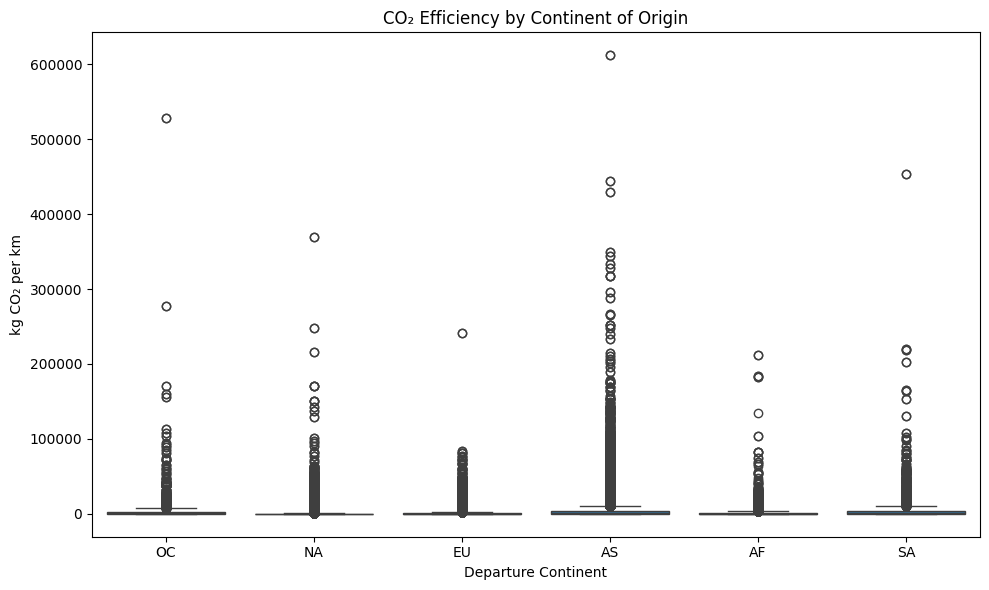

In [6]:
# Simple boxplot for the breakdown by departing continent. We see a few outliers in the case of every continent, and visually
# it is difficult to determine any big difference other than Asia departures, so we will check with ANOVA
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='departure_continent', y='co2_per_distance')
plt.title('CO₂ Efficiency by Continent of Origin')
plt.ylabel('kg CO₂ per km')
plt.xlabel('Departure Continent')
plt.tight_layout()
plt.show()

/var/folders/x0/gkxw33gj58n2ptpf02t8_ncr0000gn/T/ipykernel_8804/3827883712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='departure_continent', y='co2_per_distance', inner='box', palette='Set2')


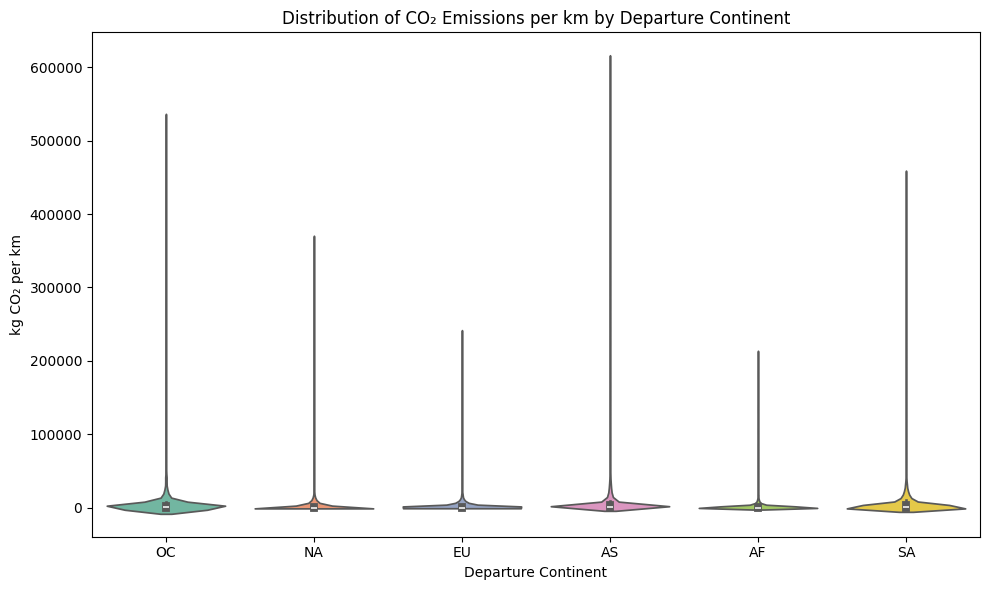

In [7]:
# Violin Plot – Shows distribution shape and outliers more clearly than a boxplot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='departure_continent', y='co2_per_distance', inner='box', palette='Set2')
plt.title('Distribution of CO₂ Emissions per km by Departure Continent')
plt.ylabel('kg CO₂ per km')
plt.xlabel('Departure Continent')
plt.tight_layout()
plt.show()

## More visualization for Tukey Test result

<Figure size 1000x600 with 0 Axes>

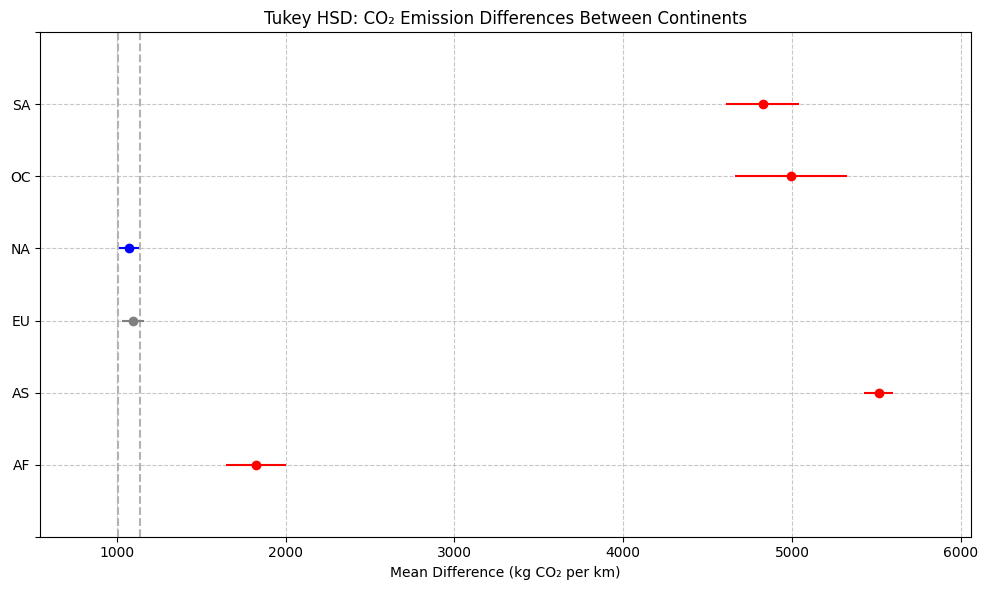

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['co2_per_distance'], groups=df['departure_continent'], alpha=0.05)

# Plot
plt.figure(figsize=(10, 6))
tukey.plot_simultaneous(comparison_name='NA')  # 'NA' as reference (you can change it)
plt.title('Tukey HSD: CO₂ Emission Differences Between Continents')
plt.xlabel('Mean Difference (kg CO₂ per km)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/var/folders/x0/gkxw33gj58n2ptpf02t8_ncr0000gn/T/ipykernel_8804/1973854694.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


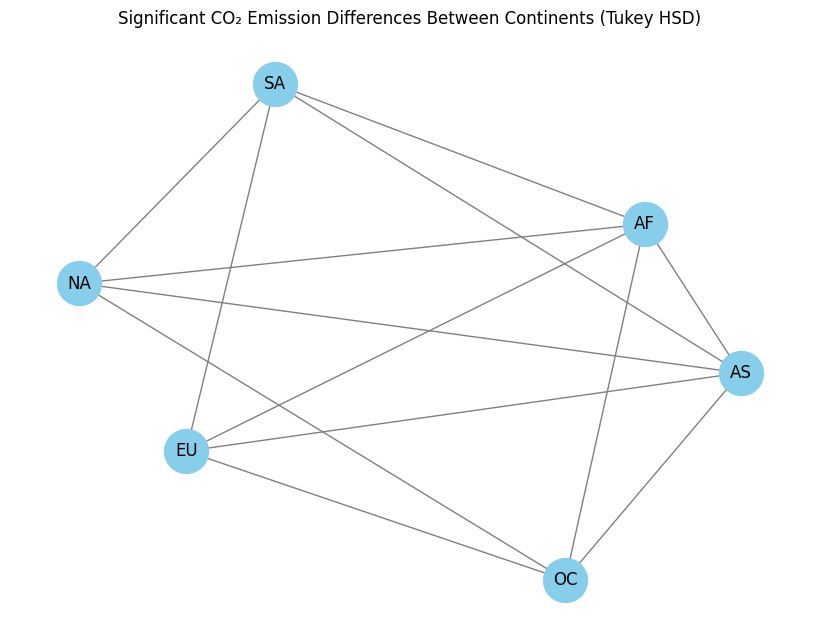

In [9]:
import networkx as nx

# Turn Tukey results into a DataFrame
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Now filter significant pairs
significant_pairs = tukey_df[tukey_df['p-adj'].astype(float) < 0.05]

# Create graph
G = nx.Graph()

# Add edges for significant pairs
for _, row in significant_pairs.iterrows():
    G.add_edge(row['group1'], row['group2'])

# Plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=12, edge_color='gray')
plt.title('Significant CO₂ Emission Differences Between Continents (Tukey HSD)')
plt.tight_layout()
plt.show()



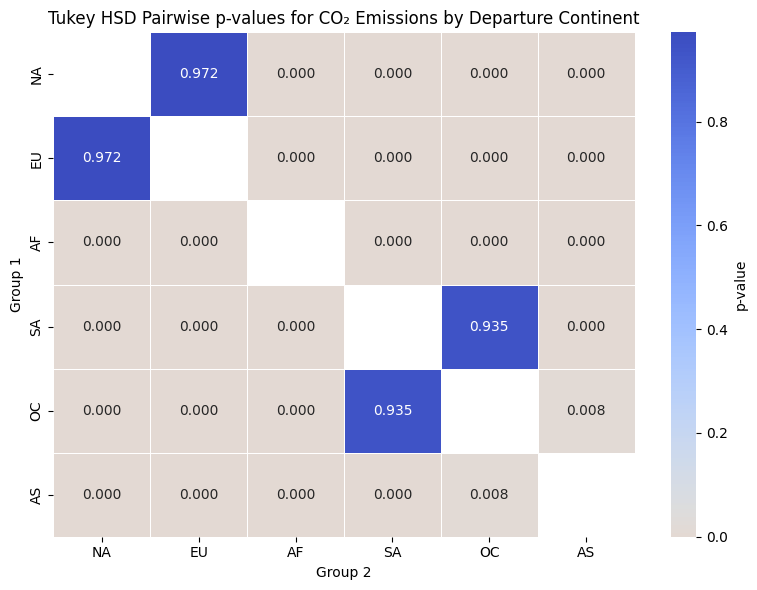

In [10]:
# 1. Turn Tukey results into a DataFrame
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# 2. Define your custom continent order
continent_order = ['NA', 'EU', 'AF', 'SA', 'OC', 'AS']

# 3. Make pivot table (p-adj values)
pivot = pd.pivot_table(
    tukey_df,
    values='p-adj',
    index='group1',
    columns='group2'
)

# 4. Complete the matrix (mirror values to make it symmetric)
pivot_full = pivot.reindex(index=continent_order, columns=continent_order)
for i in continent_order:
    for j in continent_order:
        if pd.isna(pivot_full.loc[i, j]) and not pd.isna(pivot_full.loc[j, i]):
            pivot_full.loc[i, j] = pivot_full.loc[j, i]

# Fill diagonal with 0 or NaN
for continent in continent_order:
    pivot_full.loc[continent, continent] = np.nan

# 5. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_full.astype(float), annot=True, cmap='coolwarm_r', center=0.05,
    linewidths=0.5, fmt='.3f', cbar_kws={'label': 'p-value'}
)
plt.title('Tukey HSD Pairwise p-values for CO₂ Emissions by Departure Continent')
plt.xlabel('Group 2')
plt.ylabel('Group 1')
plt.tight_layout()
plt.show()


Heatmap of Tukey HSD Pairwise p-values for CO₂ Emission Efficiency by Departure Continent.
This heatmap visualizes the p-values from the Tukey HSD test comparing mean CO₂ emissions per kilometer between departure continents. Darker shades indicate stronger statistical significance (lower p-values). Comparisons with p-values below 0.05 suggest a significant difference in emission efficiency between the two continents. The matrix is symmetric, and the diagonal is left blank as comparisons of a continent with itself are not meaningful.

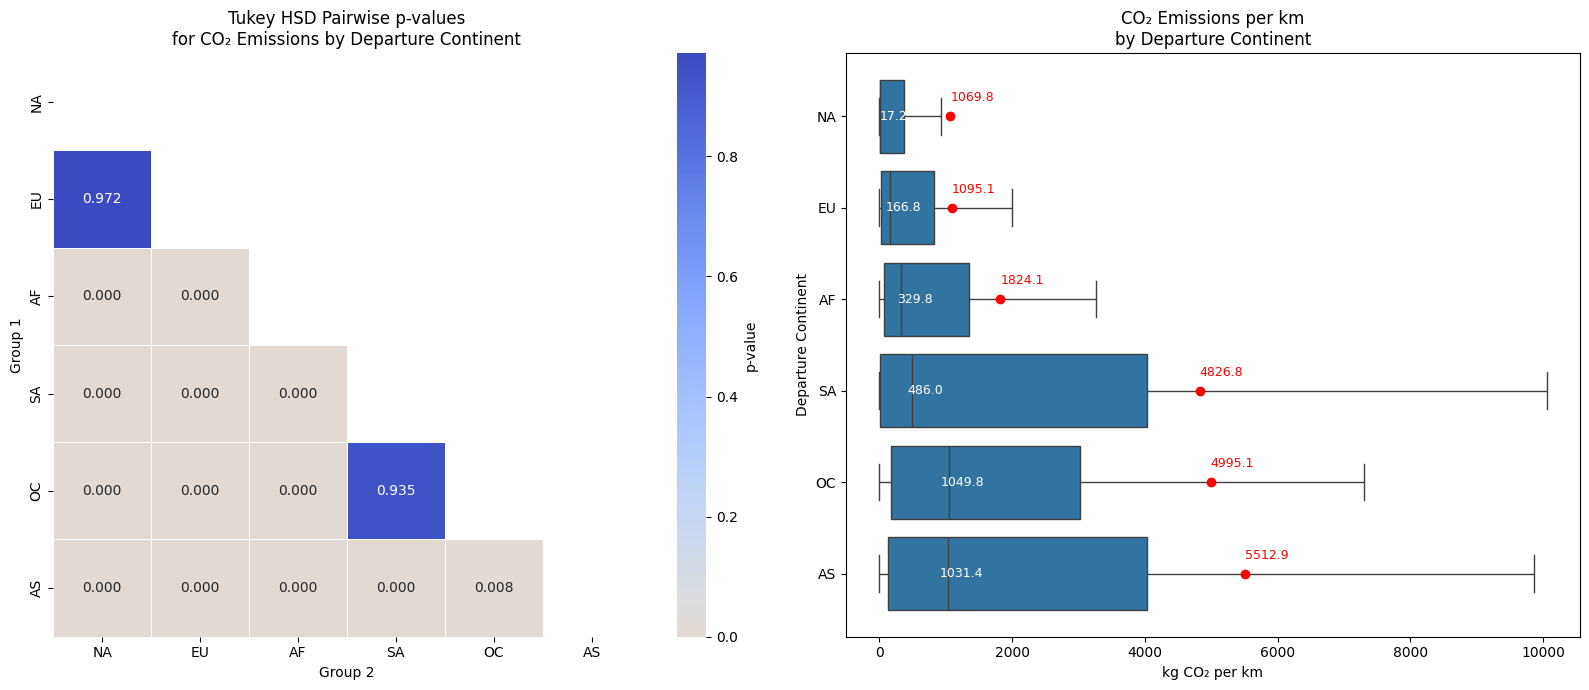

In [11]:
# --- Mask the upper triangle
mask = np.triu(np.ones_like(pivot_full, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Heatmap (masked upper triangle) ---
sns.heatmap(
    pivot_full.astype(float),
    mask=mask,
    annot=True, cmap='coolwarm_r', center=0.05,
    linewidths=0.5, fmt='.3f', cbar_kws={'label': 'p-value'},
    ax=axes[0]
)
axes[0].set_title('Tukey HSD Pairwise p-values\nfor CO₂ Emissions by Departure Continent', fontsize=12)
axes[0].set_xlabel('Group 2')
axes[0].set_ylabel('Group 1')

# --- Plot 2: Boxplot (keep full y-axis labels) ---
sns.boxplot(data=df, x='co2_per_distance', y='departure_continent',
            order=continent_order, showfliers=False, ax=axes[1])

# Add mean red dots and mean/median annotations
for i, (mean_val, median_val, continent) in enumerate(zip(continent_means.values, continent_medians.values, continent_means.index)):
    # Red dot for mean
    axes[1].plot(mean_val, i, 'ro')
    # Red text for mean
    axes[1].text(mean_val, i - 0.2, f'{mean_val:.1f}',
                 va='center', ha='left', fontsize=9, color='red')
    # White text for median
    axes[1].text(median_val + 200, i, f'{median_val:.1f}',
                 va='center', ha='center', fontsize=9, color='white')

axes[1].set_title('CO₂ Emissions per km\nby Departure Continent', fontsize=12)
axes[1].set_xlabel('kg CO₂ per km')
axes[1].set_ylabel('Departure Continent')  

plt.tight_layout()
plt.show()

Left:
Heatmap of Tukey HSD pairwise p-values for CO₂ emission efficiency between departure continents. Darker cells indicate stronger statistical differences, with p-values below 0.05 suggesting significant emission differences between continent pairs.

Right:
Boxplot of CO₂ emissions per kilometer by departure continent. Red dots represent group means, and median values are labeled next to the median bars. The visualization highlights variability and central tendencies of emission efficiency across continents.